Notebook where we construct the NSA and SAGA catalogs to compare against. The GAMA catalog is done in a different notebook

In [27]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
from astropy.cosmology import Planck18
import matplotlib.pyplot as plt
import sys
import os

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))


In [28]:
nsa_cat = Table.read("/pscratch/sd/v/virajvm/catalog/nsa_v1_0_1.fits")


In [29]:
# ELPETRO_FLUX	float32[7]	nanomaggies	Elliptical SDSS-style Petrosian flux in GALEX/SDSS FNugriz (using r-band aperture)
# nsa_cat_f = nsa_cat["RA","DEC","Z", "ELPETRO_FLUX","SRC", "IN"]

In [30]:
# nsa_cat_f = nsa_cat[nsa_cat["ZSRC"] == "sdss"]

In [31]:
gfluxs = nsa_cat["ELPETRO_FLUX"].data.data[:,3]
rfluxs = nsa_cat["ELPETRO_FLUX"].data.data[:,4]


In [32]:
gmag = 22.5-2.5*np.log10(gfluxs)
rmag = 22.5-2.5*np.log10(rfluxs)


/tmp/ipykernel_40525/1121682628.py:1: RuntimeWarning: divide by zero encountered in log10
  gmag = 22.5-2.5*np.log10(gfluxs)
/tmp/ipykernel_40525/1121682628.py:1: RuntimeWarning: invalid value encountered in log10
  gmag = 22.5-2.5*np.log10(gfluxs)
/tmp/ipykernel_40525/1121682628.py:2: RuntimeWarning: divide by zero encountered in log10
  rmag = 22.5-2.5*np.log10(rfluxs)
/tmp/ipykernel_40525/1121682628.py:2: RuntimeWarning: invalid value encountered in log10
  rmag = 22.5-2.5*np.log10(rfluxs)


In [33]:
mask = (rmag < 17.7) & (nsa_cat["ZSRC"] == 'sdss   ')

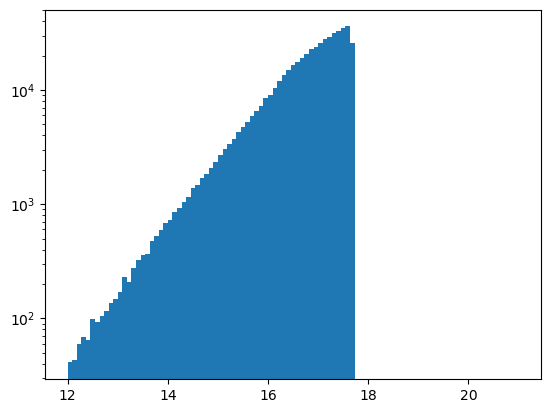

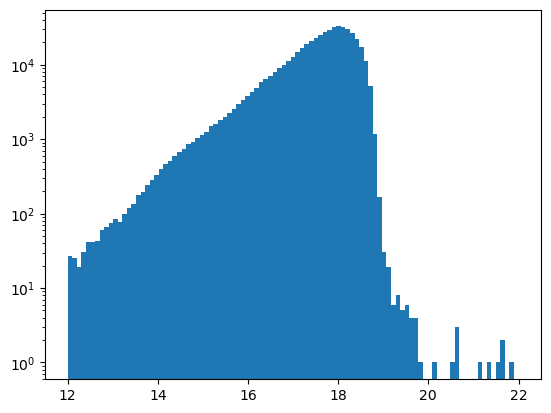

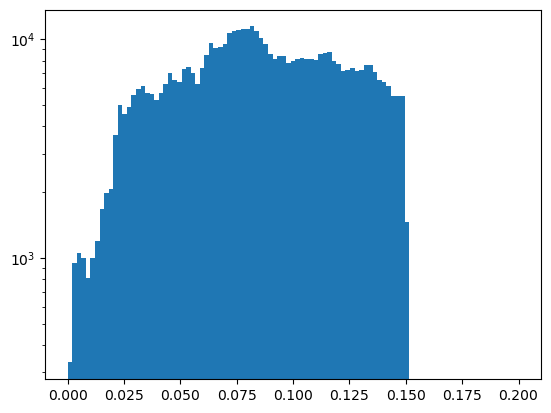

In [34]:
plt.hist(rmag[mask],bins=np.linspace(12,21,100))
plt.yscale("log")
plt.show()

plt.hist(gmag[mask],bins=np.linspace(12,22,100))
plt.yscale("log")
plt.show()

plt.hist(nsa_cat["Z"][mask],bins=np.linspace(0,0.2,100))
plt.yscale("log")
plt.show()

In [50]:
nsa_cat_mask = nsa_cat[mask]


In [51]:
np.sum(nsa_cat_mask["IN_DR7_LSS"])/len(nsa_cat_mask)

0.9576061888426218

In [52]:
np.sum(nsa_cat["IN_DR7_LSS"])/len(nsa_cat)

0.9090876492222592

In [53]:
rmag_f = rmag[mask]
gmag_f = gmag[mask]

zred_f = nsa_cat["Z"].data[mask]

ra_f = nsa_cat["RA"].data[mask]
dec_f = nsa_cat["DEC"].data[mask]



In [54]:
# print(np.sum(rmag < 17.8))
# print(np.sum(rmag < 22))

In [55]:
gr_col = gmag_f - rmag_f

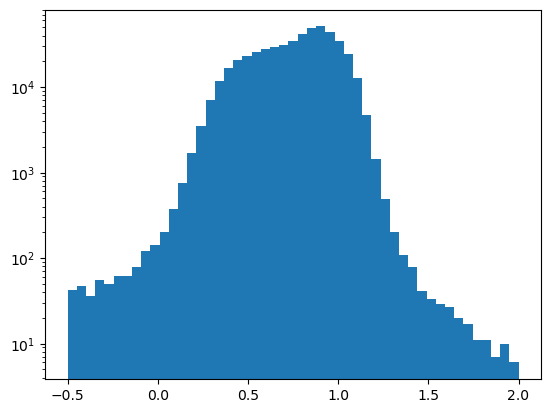

In [56]:

plt.hist(gr_col,bins=np.linspace(-0.5,2,50))
plt.yscale("log")
plt.show()


In [81]:
from desi_lowz_funcs import get_stellar_mass_mia, g_kcorr

In [82]:
mstar_vals = get_stellar_mass_mia(gr_col, gmag_f, zred_f)

/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:687: RuntimeWarning: invalid value encountered in log10
  Mg = gmag + 5 - 5 * np.log10(d_in_pc) - kg


In [83]:
##also compute the absolute mag!!

d_in_pc = Planck18.luminosity_distance(zred_f).value * 1e6

kg = g_kcorr(gr_col, zred_f)

Mg_f = gmag_f + 5 - 5 * np.log10(d_in_pc) - kg

/tmp/ipykernel_40525/1736141390.py:7: RuntimeWarning: invalid value encountered in log10
  Mg_f = gmag_f + 5 - 5 * np.log10(d_in_pc) - kg


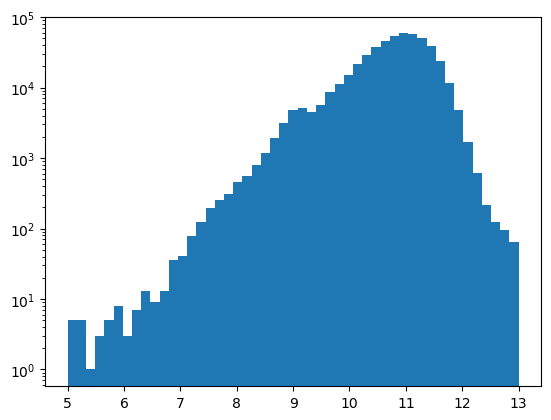

In [85]:

plt.hist(mstar_vals,bins=np.linspace(5,13,50))
plt.yscale("log")
plt.show()


In [107]:
dwarf_mask = (mstar_vals<9.25) & (mstar_vals> 6) & (gr_col > -0.5) & (Mg_f > -18.5)

#need to apply the Mg < -18.5 mask as well!

In [108]:
nsa_dwarf_tab = {"RA":ra_f[dwarf_mask], 
                "DEC": dec_f[dwarf_mask], 
                "Z": zred_f[dwarf_mask], 
                "MSTAR": mstar_vals[dwarf_mask], 
                "MAG_R": rmag_f[dwarf_mask],
                "gr_col": gr_col[dwarf_mask],
                }

nsa_dwarf_tab = Table(nsa_dwarf_tab)

In [109]:
print("6 < Mstar < 7 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 7) & (nsa_dwarf_tab["MSTAR"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 8) & (nsa_dwarf_tab["MSTAR"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 9) & (nsa_dwarf_tab["MSTAR"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 9.25) & (nsa_dwarf_tab["MSTAR"] > 9)))


6 < Mstar < 7 Counts = 83
7 < Mstar < 8 Counts = 1146
8 < Mstar < 9 Counts = 10015
9 < Mstar < 9.25 Counts = 7707


In [110]:
83+1146+10034+7819

19082

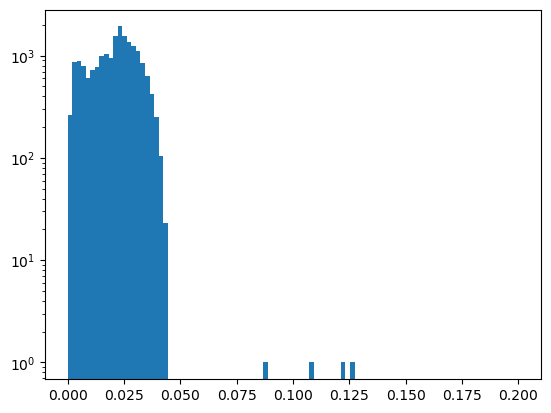

In [111]:
plt.hist(nsa_dwarf_tab["Z"],bins=np.linspace(0,0.2,100))
plt.yscale("log")
plt.show()

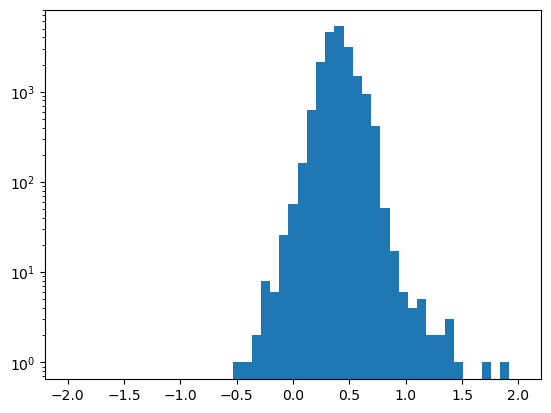

In [112]:
plt.hist(nsa_dwarf_tab["gr_col"],bins=np.linspace(-2,2,50))
plt.yscale("log")
plt.show()

In [69]:
## there is this whole junk population of gr < -0.5 gaalxies.

In [92]:
## SAVE THIS CATALOG

nsa_dwarf_tab.write("/pscratch/sd/v/virajvm/catalog/nsa_dwarf_catalog.fits",overwrite=True)

# SAGA+SAGAbg dwarf counts

In [93]:
from astropy.table import Table
saga_gals = Table.read('https://sagasurvey.org/data/saga-dr3-tableC2.txt', format='ascii.mrt')
print(len(saga_gals))

75704


In [94]:
print(np.sum( (saga_gals["log(M*)"] < 9.25) & (saga_gals["log(M*)"] > 6) )  )

10263


In [95]:
rmags_saga = saga_gals["rmag"].data
gmags_saga = saga_gals["gr"].data + saga_gals["rmag"].data
zreds_saga = saga_gals["z"].data

In [96]:
mstar_saga = get_stellar_mass_mia(saga_gals["gr"].data, gmags_saga, zreds_saga)

In [97]:
##also compute the absolute mag!!

d_in_pc = Planck18.luminosity_distance(zreds_saga).value * 1e6

kg = g_kcorr(saga_gals["gr"].data, zreds_saga)

Mg_sga = gmags_saga + 5 - 5 * np.log10(d_in_pc) - kg

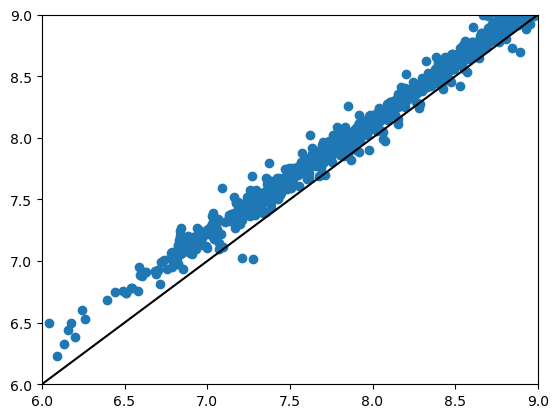

In [98]:
plt.scatter(saga_gals["log(M*)"].data, mstar_saga)
plt.xlim([6,9])
plt.ylim([6,9])
plt.plot([6,9],[6,9],color="k")
plt.show()

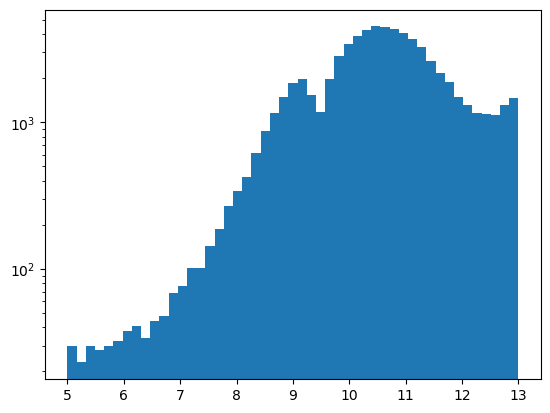

In [99]:

plt.hist(mstar_saga,bins=np.linspace(5,13,50))
plt.yscale("log")
plt.show()


In [100]:
print(np.sum( (mstar_saga < 9.25) & (mstar_saga > 6) )  )

saga_dwarf_mask = (mstar_saga < 9.25) & (mstar_saga > 6) & (Mg_sga > -18.5)

9931


In [101]:
saga_gals["MSTAR"] = mstar_saga

In [102]:
saga_dwarf_gals = saga_gals[saga_dwarf_mask]

In [103]:
saga_dwarf_gals.write("/pscratch/sd/v/virajvm/catalog/saga_dr3_dwarf_cat.fits",overwrite=True)

In [104]:
len(saga_dwarf_gals)

9904

In [105]:

print("6 < Mstar < 7 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 7) & (saga_dwarf_gals["MSTAR"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 8) & (saga_dwarf_gals["MSTAR"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 9) & (saga_dwarf_gals["MSTAR"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 9.25) & (saga_dwarf_gals["MSTAR"] > 9)))


6 < Mstar < 7 Counts = 279
7 < Mstar < 8 Counts = 994
8 < Mstar < 9 Counts = 5650
9 < Mstar < 9.25 Counts = 2981
